<style>
  td, th {
    border: none!important;
    font-family: Arial, sans-serif;
    padding: 8px;
  }
  th {
    font-weight: bold;
  }
</style>

| Notebook Details |  |
|----|---|
|Host | Montanuniversitaet Leoben |
|Course | Mechanics of Composite Materials |
|Authors | Vasco D.C Pires |
|Department | Chair of Designing Plastics and Composite Materials|
|Corresponding Authors | vasco.castro-pires@unileoben.ac.at |
|Last edited |  17.03.2026 |

<div>
<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTWeMORYjOsTvgceJjHADfsEqLMHCPqPjUDnw&s" width="150"/>
</div>

# Python notebook - Practical Class 4

<div class="alert alert-block alert-success">
This practical notebook focuses only on stress rotation in plane stress, with simple code for teaching and classroom use.
</div>

## Contents
***
[1) Rotation basics (plane stress)](#1-rotation-basics-plane-stress)

[2) Simple Python function for rotation](#2-simple-python-function-for-rotation)

[3) One worked example](#3-one-worked-example)

[4) Angle sweep plot](#4-angle-sweep-plot)

[5) Mini exercises](#5-mini-exercises)

# 1) Rotation basics (plane stress)

For a 2D (plane stress) state we write:

$$\boldsymbol{\sigma}=\begin{bmatrix}\sigma_x & \sigma_y & \tau_{xy}\end{bmatrix}^{T}$$

After rotating the axes by an angle $\theta$, with $c=\cos\theta$ and $s=\sin\theta$, we get:

$$\sigma_{x'} = c^2\sigma_x + s^2\sigma_y + 2cs\tau_{xy}$$
$$\sigma_{y'} = s^2\sigma_x + c^2\sigma_y - 2cs\tau_{xy}$$
$$\tau_{x'y'} = -cs\sigma_x + cs\sigma_y + (c^2-s^2)\tau_{xy}$$

We use these expressions directly in Python below.

In [16]:
#!pip install matplotlib

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 2) Simple Python function for rotation

In [18]:
def rotate_plane_stress(sigma_x, sigma_y, tau_xy, theta_deg):
    """Rotate a plane stress state by theta_deg (degrees)."""
    theta = np.deg2rad(theta_deg)
    c = np.cos(theta)
    s = np.sin(theta)

    sigma_x_p = c**2 * sigma_x + s**2 * sigma_y + 2 * s * c * tau_xy
    sigma_y_p = s**2 * sigma_x + c**2 * sigma_y - 2 * s * c * tau_xy
    tau_xpyp = -s * c * sigma_x + s * c * sigma_y + (c**2 - s**2) * tau_xy

    return sigma_x_p, sigma_y_p, tau_xpyp

# 3) One worked example

Use a stress state in MPa and rotate it by 30 degrees.

In [19]:
sigma_x = 120.0  # MPa
sigma_y = 40.0   # MPa
tau_xy = 30.0    # MPa
theta = 30.0     # deg

sigma_x_p, sigma_y_p, tau_xpyp = rotate_plane_stress(sigma_x, sigma_y, tau_xy, theta)

print(f"Input stress state (MPa): sx={sigma_x:.2f}, sy={sigma_y:.2f}, txy={tau_xy:.2f}")
print(f"Rotation angle: {theta:.1f} deg")
print(f"Rotated stress state (MPa): sx'={sigma_x_p:.2f}, sy'={sigma_y_p:.2f}, tx'y'={tau_xpyp:.2f}")

# Optional check: rotate back by -theta
sx_back, sy_back, txy_back = rotate_plane_stress(sigma_x_p, sigma_y_p, tau_xpyp, -theta)
print("\nBack-rotation check (should match input):")
print(f"sx={sx_back:.2f}, sy={sy_back:.2f}, txy={txy_back:.2f}")

Input stress state (MPa): sx=120.00, sy=40.00, txy=30.00
Rotation angle: 30.0 deg
Rotated stress state (MPa): sx'=125.98, sy'=34.02, tx'y'=-19.64

Back-rotation check (should match input):
sx=120.00, sy=40.00, txy=30.00


# 4) Angle sweep plot

Now rotate the same stress state from 0 to 180 degrees and plot all components.

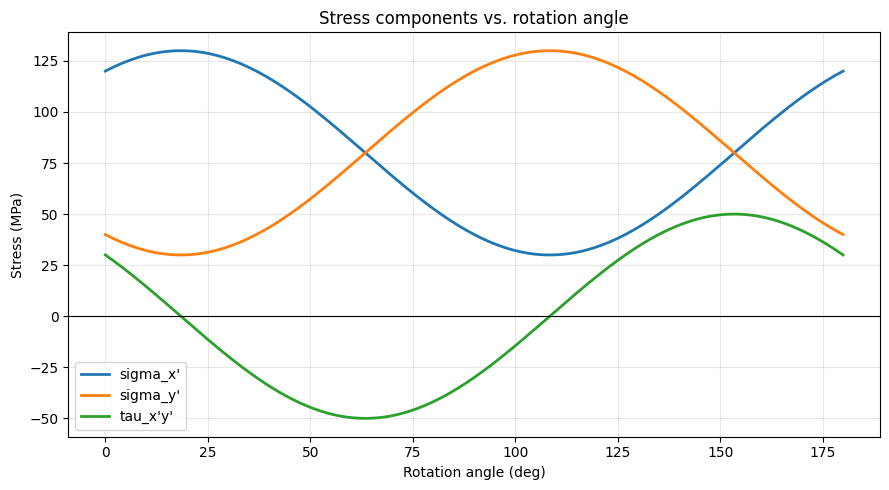

In [20]:
angles = np.linspace(0.0, 180.0, 181)
sigma_x_rot = np.zeros_like(angles)
sigma_y_rot = np.zeros_like(angles)
tau_xy_rot = np.zeros_like(angles)

for i, angle in enumerate(angles):
    sx_p, sy_p, txy_p = rotate_plane_stress(sigma_x, sigma_y, tau_xy, angle)
    sigma_x_rot[i] = sx_p
    sigma_y_rot[i] = sy_p
    tau_xy_rot[i] = txy_p

plt.figure(figsize=(9, 5))
plt.plot(angles, sigma_x_rot, label="sigma_x'", linewidth=2)
plt.plot(angles, sigma_y_rot, label="sigma_y'", linewidth=2)
plt.plot(angles, tau_xy_rot, label="tau_x'y'", linewidth=2)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Rotation angle (deg)")
plt.ylabel("Stress (MPa)")
plt.title("Stress components vs. rotation angle")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### How does stiffness change? (orthotropic vs isotropic)

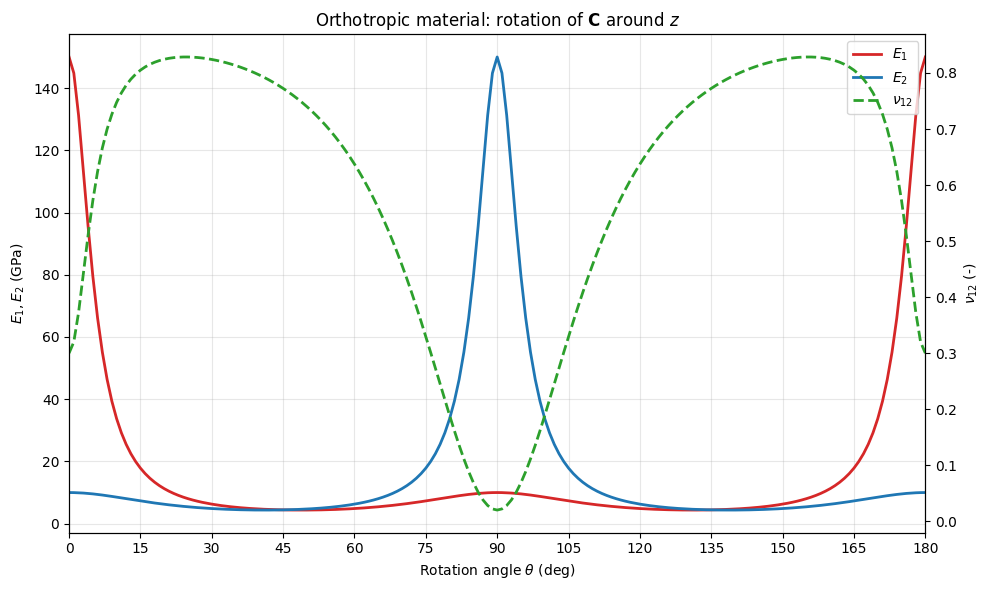

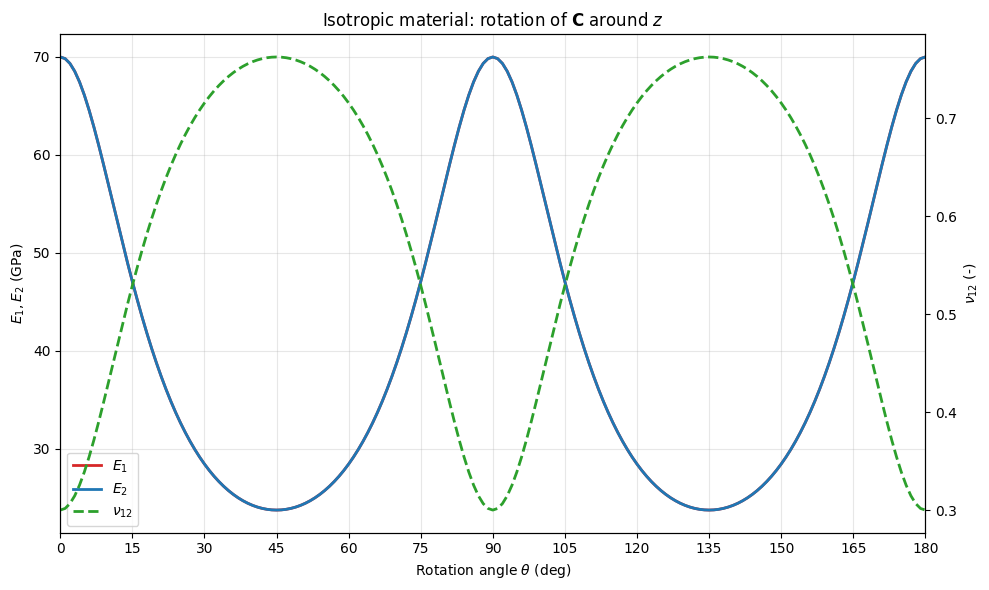

In [21]:
def z_rotation_stress_matrix(theta_deg):
    theta = np.deg2rad(theta_deg)
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [c**2, s**2, 0.0, -2.0*s*c, 0.0, 0.0],
        [s**2, c**2, 0.0,  2.0*s*c, 0.0, 0.0],
        [0.0,  0.0,  1.0,  0.0,     0.0, 0.0],
        [s*c, -s*c,  0.0,  c**2-s**2, 0.0, 0.0],
        [0.0,  0.0,  0.0,  0.0,     c,  -s],
        [0.0,  0.0,  0.0,  0.0,     s,   c]
    ])


def rotate_stiffness_z(C_local, theta_deg):
    T_sigma = z_rotation_stress_matrix(theta_deg)
    T_sigma_inv = np.linalg.inv(T_sigma)
    return T_sigma_inv.T @ C_local @ T_sigma_inv


def engineering_constants_from_stiffness(C):
    S = np.linalg.inv(C)
    E1 = 1.0 / S[0, 0]
    E2 = 1.0 / S[1, 1]
    nu12 = -S[0, 1] / S[0, 0]
    return E1, E2, nu12


def plot_rotated_constants(angles, E1_vals, E2_vals, nu12_vals, title):
    fig, ax1 = plt.subplots(figsize=(10, 6))
    p1 = ax1.plot(angles, E1_vals, color='tab:red', linewidth=2, label=r'$E_1$')
    p2 = ax1.plot(angles, E2_vals, color='tab:blue', linewidth=2, label=r'$E_2$')
    ax1.set_xlabel(r'Rotation angle $\theta$ (deg)')
    ax1.set_ylabel(r'$E_1, E_2$ (GPa)')
    ax1.set_xlim(0, 180)
    ax1.set_xticks(np.arange(0, 181, 15))
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    p3 = ax2.plot(angles, nu12_vals, color='tab:green', linestyle='--', linewidth=2, label=r'$\nu_{12}$')
    ax2.set_ylabel(r'$\nu_{12}$ (-)')

    lines = p1 + p2 + p3
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc='best')
    plt.title(title)
    plt.tight_layout()
    plt.show()


angles = np.linspace(0.0, 180.0, 181)

# ------------------------------
# Orthotropic material example
# ------------------------------
S_ortho = np.array([
    [1/150,    -0.3/150, -0.3/150, 0,   0,   0],
    [-0.3/150, 1/10,    -0.4/10,  0,   0,   0],
    [-0.3/150,-0.4/10,   1/10,    0,   0,   0],
    [0,        0,        0,       1/5, 0,   0],
    [0,        0,        0,       0,   1/5, 0],
    [0,        0,        0,       0,   0,   1/7]
], dtype=float)

C_ortho = np.linalg.inv(S_ortho)
E1_ortho = np.zeros_like(angles)
E2_ortho = np.zeros_like(angles)
nu12_ortho = np.zeros_like(angles)

for i, angle in enumerate(angles):
    C_rot = rotate_stiffness_z(C_ortho, angle)
    E1_ortho[i], E2_ortho[i], nu12_ortho[i] = engineering_constants_from_stiffness(C_rot)

plot_rotated_constants(
    angles,
    E1_ortho,
    E2_ortho,
    nu12_ortho,
    title=r'Orthotropic material: rotation of $\mathbf{C}$ around $z$'
)

# ----------------------------
# Isotropic material example
# ----------------------------
E_iso = 70.0
nu_iso = 0.30
G_iso = E_iso / (2.0 * (1.0 + nu_iso))

S_iso = np.array([
    [1/E_iso,   -nu_iso/E_iso, -nu_iso/E_iso, 0,     0,     0],
    [-nu_iso/E_iso, 1/E_iso,   -nu_iso/E_iso, 0,     0,     0],
    [-nu_iso/E_iso, -nu_iso/E_iso, 1/E_iso,   0,     0,     0],
    [0,         0,         0,         1/G_iso, 0,     0],
    [0,         0,         0,         0,     1/G_iso, 0],
    [0,         0,         0,         0,     0,     1/G_iso]
], dtype=float)

C_iso = np.linalg.inv(S_iso)
E1_iso_vals = np.zeros_like(angles)
E2_iso_vals = np.zeros_like(angles)
nu12_iso_vals = np.zeros_like(angles)

for i, angle in enumerate(angles):
    C_rot = rotate_stiffness_z(C_iso, angle)
    E1_iso_vals[i], E2_iso_vals[i], nu12_iso_vals[i] = engineering_constants_from_stiffness(C_rot)

plot_rotated_constants(
    angles,
    E1_iso_vals,
    E2_iso_vals,
    nu12_iso_vals,
    title=r'Isotropic material: rotation of $\mathbf{C}$ around $z$'
)